In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matlab as mlt
df=pd.read_csv("heart.csv")
print(df)
df.dropna()
df.describe()
df.info()
df.drop_duplicates()
df.columns.to_list()


      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target   
0         2   2     3        0  
1        

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target ']

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7853658536585366
[[71 31]
 [13 90]]
False positive0,1
False positive0,1
False positive0,1
False positive0,1
False positive0,1
False negative:1,0
False positive0,1
False positive0,1
False negative:1,0
False positive0,1
False positive0,1
False negative:1,0
False negative:1,0
False positive0,1
False positive0,1
False positive0,1
False positive0,1
False positive0,1
False positive0,1
False negative:1,0
False positive0,1
False positive0,1
False positive0,1
False negative:1,0
False negative:1,0
False positive0,1
False positive0,1
False negative:1,0
False positive0,1
False negative:1,0
False positive0,1
False positive0,1
False positive0,1
False negative:1,0
False negative:1,0
False negative:1,0
False positive0,1
False positive0,1
False positive0,1
False positive0,1
False positive0,1
False positive0,1
False negative:1,0
False positive0,1
              precision    recall  f1-score   support

           0       0.85      0.70      0.76       102
           1       0.74      0.87      0.80     

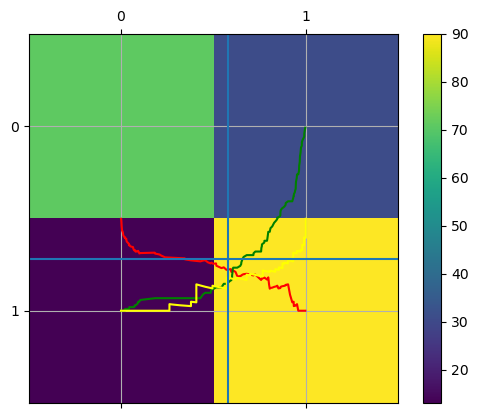

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_recall_curve,average_precision_score
X=df.drop('target ',axis=1)
y=df['target ']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LogisticRegression()
model.fit(X_train,y_train)
# y_pred=model.predict(X_test)
# print(y_pred)
probability=model.predict_proba(X_test)[:,1]
prediction_threshold=(probability>=0.5).astype(int)
print(accuracy_score(y_test,prediction_threshold))
cm=confusion_matrix(y_test,prediction_threshold)
print(cm)
for actual,predicted in zip(y_test,prediction_threshold):
    if actual==1 and predicted==0:
        print(f"False negative:{actual},{predicted}")
    if actual==0 and predicted==1:
        print(f"False positive{actual},{predicted}")
print(classification_report(y_test,prediction_threshold))
print(f"Prediction:{prediction_threshold}")
# print(f"probability:{probability}")
precision,recall,thresholds=precision_recall_curve(y_test,probability)
ap_score=average_precision_score(y_test,probability)
fig,ax=plt.subplots()
ax.plot(thresholds,precision[:-1],color='red',label="precision curve")
ax.plot(thresholds,recall[:-1],color='green',label="recall curve")
ax.plot(recall,precision,color='yellow',label=f'PR curve:{ap_score}')
ax.axvline(0.58)
ax.axhline(0.72)
plt.grid(True)
ax.matshow(cm,cmap='tab10',alpha=0.5)
plt.colorbar(plt.imshow(cm))
plt.show()
plt.close()